Success: Paper detected.


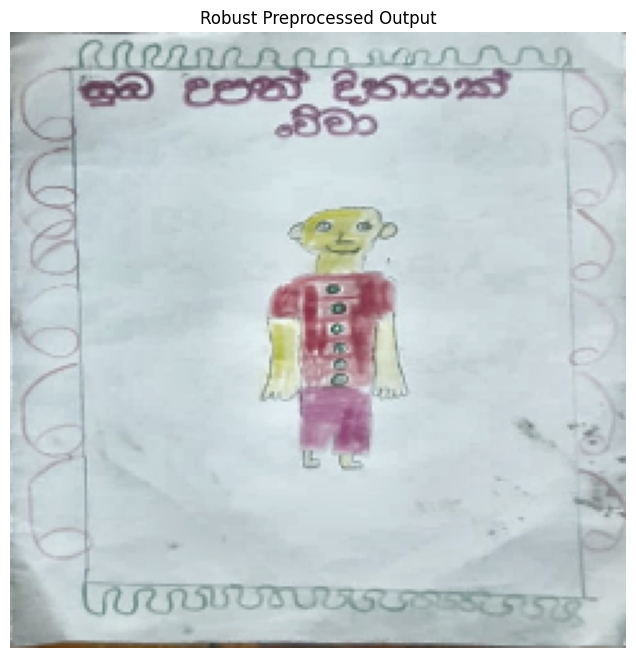

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Define the target size
TARGET_SIZE = (240, 240)

def order_points(pts):
    """Orders coordinates: top-left, top-right, bottom-right, bottom-left."""
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def find_paper_contour(img):
    """
    Improved Paper Detection:
    - Uses morphological closing to connect broken lines.
    - Sorts by Area to ignore small clutter.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. Blur heavily to ignore details inside the drawing
    blurred = cv2.GaussianBlur(gray, (9, 9), 0)

    # 2. Canny Edge Detection
    # Lower values to catch faint edges
    edged = cv2.Canny(blurred, 30, 200)

    # 3. Morphological Close (Connects gaps in the paper edge)
    # Crucial for the "Person" drawing where the edge might be faint
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    closed = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel)

    # 4. Find Contours
    contours, _ = cv2.findContours(closed.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Sort by area (Keep largest)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    for c in contours:
        # Approximate the contour
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)

        # If it has 4 points and is reasonably large
        if len(approx) == 4 and cv2.contourArea(c) > 5000:
            return approx

    return None

def universal_enhancer(img):
    """
    The 'Safe' Enhancer.
    Instead of bleaching the image (which ruins color), this boosts contrast
    in the Lightness channel.
    - Works for Pencil (Makes gray dark)
    - Works for Crayon (Makes colors pop)
    - Never turns image grayscale
    """
    # 1. Convert BGR to LAB (L = Lightness, A/B = Colors)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # 2. Apply CLAHE (Contrast Limiting) to L-Channel ONLY
    # This makes the darks darker and lights lighter without shifting colors
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    # 3. Merge back
    limg = cv2.merge((cl, a, b))

    # 4. Convert back to BGR
    enhanced = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    # 5. Optional: Slight Gamma Correction to brighten mid-tones (fix dim photos)
    # Gamma < 1.0 makes image brighter
    gamma = 0.8
    lookUpTable = np.empty((1, 256), np.uint8)
    for i in range(256):
        lookUpTable[0, i] = np.clip(pow(i / 255.0, gamma) * 255.0, 0, 255)
    final = cv2.LUT(enhanced, lookUpTable)

    return final

def process_drawing(image_path, output_size=TARGET_SIZE):
    if not os.path.exists(image_path):
        print("Error: File not found")
        return None

    img = cv2.imread(image_path)
    orig = img.copy()

    # --- STEP 1: CROP ---
    screenCnt = find_paper_contour(img)

    if screenCnt is not None:
        pts = screenCnt.reshape(4, 2)
        rect = order_points(pts)
        (tl, tr, br, bl) = rect

        widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
        widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
        maxWidth = max(int(widthA), int(widthB))

        heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
        heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
        maxHeight = max(int(heightA), int(heightB))

        dst = np.array([[0, 0], [maxWidth-1, 0], [maxWidth-1, maxHeight-1], [0, maxHeight-1]], dtype="float32")
        M = cv2.getPerspectiveTransform(rect, dst)
        warped = cv2.warpPerspective(orig, M, (maxWidth, maxHeight))
        print("Success: Paper detected.")
    else:
        # FALLBACK: If we can't find the 4 corners, use the Center Crop.
        # This prevents the 'tiny white box' error.
        print("Warning: Edges not clear. Using Center Crop fallback.")
        h, w = img.shape[:2]
        # Crop the center 80% of the image
        cy, cx = h // 2, w // 2
        dy, dx = int(h * 0.4), int(w * 0.4)
        warped = img[cy-dy:cy+dy, cx-dx:cx+dx]

    # --- STEP 2: RESIZE ---
    resized = cv2.resize(warped, output_size, interpolation=cv2.INTER_AREA)

    # --- STEP 3: ENHANCE (Universal Method) ---
    final_output = universal_enhancer(resized)

    return final_output

# --- EXECUTION ---
# Change this to your filename
input_file = "wood bg1.jpeg"

result = process_drawing(input_file)

if result is not None:
    # Convert for Matplotlib
    display_img = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(display_img)
    plt.title("Robust Preprocessed Output")
    plt.axis('off')
    plt.show()

    cv2.imwrite("robust_output.jpg", result)